<a href="https://colab.research.google.com/github/anupsubbu98/Kaggle-Competitions/blob/main/Abd_vs_Bumrah.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)

In [ ]:
df = pd.read_csv('IPL_ball_by_ball_updated.csv')
df.head(3)

,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,bowler,runs_off_bat,extras,wides,noballs,byes,legbyes,penalty,wicket_type,player_dismissed,other_wicket_type,other_player_dismissed
0,335982,2008,2008-04-18,M Chinnaswamy Stadium,2,6.8,Royal Challengers Bangalore,Kolkata Knight Riders,MV Boucher,CL White,AB Agarkar,4,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,335982,2008,2008-04-18,M Chinnaswamy Stadium,2,2.7,Royal Challengers Bangalore,Kolkata Knight Riders,W Jaffer,JH Kallis,AB Dinda,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,335982,2008,2008-04-18,M Chinnaswamy Stadium,2,3.1,Royal Challengers Bangalore,Kolkata Knight Riders,W Jaffer,JH Kallis,I Sharma,2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# df = df.drop(columns={'match_id'})
df.innings.unique()

array([2, 1, 4, 3, 6, 5])

In [ ]:
df = df[(df.innings==1) | (df.innings==2)]

In [ ]:
df.striker.unique()

array(['MV Boucher', 'W Jaffer', 'JH Kallis', 'CL White', 'V Kohli',
       'BB McCullum', 'Mohammad Hafeez', 'R Dravid', 'P Kumar', 'Z Khan',
       'SB Joshi', 'AA Noffke', 'B Akhil', 'SC Ganguly', 'RT Ponting',
       'DJ Hussey', 'M Kaif', 'M Rawat', 'RA Jadeja', 'DS Lehmann',
       'SK Warne', 'D Salunkhe', 'SM Katich', 'YK Pathan', 'T Kohli',
       'IK Pathan', 'SR Watson', 'S Dhawan', 'G Gambhir', 'V Sehwag',
       'SK Trivedi', 'KC Sangakkara', 'MEK Hussey', 'JDP Oram',
       'SK Raina', 'S Badrinath', 'ML Hayden', 'PA Patel', 'MS Dhoni',
       'Yuvraj Singh', 'JR Hopes', 'K Goel', 'AS Yadav', 'A Symonds',
       'SB Styris', 'SB Bangar', 'RP Singh', 'WPUJC Vaas', 'AC Gilchrist',
       'VVS Laxman', 'Y Venugopal Rao', 'WP Saha', 'RG Sharma',
       'LR Shukla', 'RV Uthappa', 'AM Nayar', 'PR Shah', 'SM Pollock',
       'Harbhajan Singh', 'ST Jayasuriya', 'DJ Thornely', 'L Ronchi',
       'LRPL Taylor', 'S Chanderpaul', 'Kamran Akmal', 'PP Chawla',
       'DPMD Jayawardene'

In [ ]:
#Filter the data by player names

In [ ]:
adf = df[df['striker'] == 'AB de Villiers']
adf.head(3)

,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,bowler,runs_off_bat,extras,wides,noballs,byes,legbyes,penalty,wicket_type,player_dismissed,other_wicket_type,other_player_dismissed
4575,336001,2008,2008-05-02,"MA Chidambaram Stadium, Chepauk",2,14.6,Delhi Daredevils,Chennai Super Kings,AB de Villiers,S Dhawan,MS Gony,2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4578,336001,2008,2008-05-02,"MA Chidambaram Stadium, Chepauk",2,15.3,Delhi Daredevils,Chennai Super Kings,AB de Villiers,S Dhawan,M Ntini,2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4579,336001,2008,2008-05-02,"MA Chidambaram Stadium, Chepauk",2,15.4,Delhi Daredevils,Chennai Super Kings,AB de Villiers,S Dhawan,M Ntini,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df1 = df[df['bowling_team'] == 'Mumbai Indians']
df1['bowler'].unique()

array(['DS Kulkarni', 'Harbhajan Singh', 'A Nehra', 'AM Nayar',
       'ST Jayasuriya', 'SM Pollock', 'MA Khote', 'DJ Bravo',
       'VS Yeligati', 'SD Chitnis', 'CRD Fernando', 'DJ Thornely',
       'RR Raje', 'DR Smith', 'A Nel', 'SL Malinga', 'Z Khan',
       'SR Tendulkar', 'JP Duminy', 'GR Napier', 'C Nanda', 'AM Rahane',
       'RA Shaikh', 'R McLaren', 'R Sathish', 'AG Murtaza', 'KA Pollard',
       'AN Ahmed', 'STR Binny', 'JEC Franklin', 'MM Patel', 'RG Sharma',
       'A Symonds', 'TL Suman', 'RW Price', 'PP Ojha', 'RP Singh',
       'CJ McKay', 'NLTC Perera', 'RJ Peterson', 'R Shukla', 'JJ Bumrah',
       'MG Johnson', 'JDP Oram', 'R Dhawan', 'YS Chahal', 'P Suyal',
       'GJ Maxwell', 'NM Coulter-Nile', 'CJ Anderson', 'P Kumar',
       'LMP Simmons', 'S Gopal', 'K Santokie', 'M de Lange',
       'R Vinay Kumar', 'J Suchith', 'MJ McClenaghan', 'HH Pandya',
       'TG Southee', 'KH Pandya', 'N Rana', 'KV Sharma', 'M Markande',
       'Mustafizur Rahman', 'PJ Sangwan', 'BCJ C

In [ ]:
bdf = df[df['bowler']=='JJ Bumrah']
bdf.head(3)

,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,bowler,runs_off_bat,extras,wides,noballs,byes,legbyes,penalty,wicket_type,player_dismissed,other_wicket_type,other_player_dismissed
76627,597999,2013,2013-04-04,M Chinnaswamy Stadium,1,12.6,Royal Challengers Bangalore,Mumbai Indians,CH Gayle,KB Arun Karthik,JJ Bumrah,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
76628,597999,2013,2013-04-04,M Chinnaswamy Stadium,1,12.5,Royal Challengers Bangalore,Mumbai Indians,KB Arun Karthik,CH Gayle,JJ Bumrah,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
76629,597999,2013,2013-04-04,M Chinnaswamy Stadium,1,12.4,Royal Challengers Bangalore,Mumbai Indians,KK Nair,CH Gayle,JJ Bumrah,0,0,NaN,NaN,NaN,NaN,NaN,lbw,KK Nair,NaN,NaN


In [ ]:
final_df = df[(df['striker']=='AB de Villiers') & (df['bowler']=='JJ Bumrah')]
final_df

,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,bowler,runs_off_bat,extras,wides,noballs,byes,legbyes,penalty,wicket_type,player_dismissed,other_wicket_type,other_player_dismissed
95691,729287,2014,2014-04-19,Dubai International Cricket Stadium,2,6.1,Royal Challengers Bangalore,Mumbai Indians,AB de Villiers,PA Patel,JJ Bumrah,2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
95692,729287,2014,2014-04-19,Dubai International Cricket Stadium,2,6.2,Royal Challengers Bangalore,Mumbai Indians,AB de Villiers,PA Patel,JJ Bumrah,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
95695,729287,2014,2014-04-19,Dubai International Cricket Stadium,2,6.4,Royal Challengers Bangalore,Mumbai Indians,AB de Villiers,PA Patel,JJ Bumrah,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
95928,729287,2014,2014-04-19,Dubai International Cricket Stadium,2,11.6,Royal Challengers Bangalore,Mumbai Indians,AB de Villiers,PA Patel,JJ Bumrah,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
95942,729287,2014,2014-04-19,Dubai International Cricket Stadium,2,11.1,Royal Challengers Bangalore,Mumbai Indians,AB de Villiers,PA Patel,JJ Bumrah,6,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
95943,729287,2014,2014-04-19,Dubai International Cricket Stadium,2,11.2,Royal Challengers Bangalore,Mumbai Indians,AB de Villiers,PA Patel,JJ Bumrah,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
95944,729287,2014,2014-04-19,Dubai International Cricket Stadium,2,11.3,Royal Challengers Bangalore,Mumbai Indians,AB de Villiers,PA Patel,JJ Bumrah,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
95946,729287,2014,2014-04-19,Dubai International Cricket Stadium,2,11.5,Royal Challengers Bangalore,Mumbai Indians,AB de Villiers,PA Patel,JJ Bumrah,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100873,733983,2014,2014-05-06,Wankhede Stadium,2,12.4,Royal Challengers Bangalore,Mumbai Indians,AB de Villiers,V Kohli,JJ Bumrah,0,0,NaN,NaN,NaN,NaN,NaN,bowled,AB de Villiers,NaN,NaN
100874,733983,2014,2014-05-06,Wankhede Stadium,2,12.3,Royal Challengers Bangalore,Mumbai Indians,AB de Villiers,V Kohli,JJ Bumrah,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#No.of Runs Scored
#No.of Balls Faced
#No.of times dismissed
#SR

In [ ]:
final_df = final_df.drop(columns={'match_id','start_date','venue','innings','extras','wides','noballs','byes','legbyes','penalty','other_wicket_type','other_player_dismissed'})
final_df.head()

,season,ball,batting_team,bowling_team,striker,non_striker,bowler,runs_off_bat,wicket_type,player_dismissed
95691,2014,6.1,Royal Challengers Bangalore,Mumbai Indians,AB de Villiers,PA Patel,JJ Bumrah,2,NaN,NaN
95692,2014,6.2,Royal Challengers Bangalore,Mumbai Indians,AB de Villiers,PA Patel,JJ Bumrah,1,NaN,NaN
95695,2014,6.4,Royal Challengers Bangalore,Mumbai Indians,AB de Villiers,PA Patel,JJ Bumrah,1,NaN,NaN
95928,2014,11.6,Royal Challengers Bangalore,Mumbai Indians,AB de Villiers,PA Patel,JJ Bumrah,0,NaN,NaN
95942,2014,11.1,Royal Challengers Bangalore,Mumbai Indians,AB de Villiers,PA Patel,JJ Bumrah,6,NaN,NaN


In [ ]:
final_df['runs_off_bat'].sum()

125

In [ ]:
#No of balls faced by ABD
len(final_df)

86

In [ ]:
(final_df['player_dismissed'] =='AB de Villiers').sum()

3

In [ ]:
(final_df['runs_off_bat'].sum()/len(final_df))*100

145.3488372093023

In [ ]:
#Comparing against all batsman Bumrah has bowled

In [ ]:
bdf.head(2)

,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,bowler,runs_off_bat,extras,wides,noballs,byes,legbyes,penalty,wicket_type,player_dismissed,other_wicket_type,other_player_dismissed
76627,597999,2013,2013-04-04,M Chinnaswamy Stadium,1,12.6,Royal Challengers Bangalore,Mumbai Indians,CH Gayle,KB Arun Karthik,JJ Bumrah,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
76628,597999,2013,2013-04-04,M Chinnaswamy Stadium,1,12.5,Royal Challengers Bangalore,Mumbai Indians,KB Arun Karthik,CH Gayle,JJ Bumrah,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
bdf1 = pd.DataFrame(bdf['runs_off_bat'].groupby(bdf['striker']).sum()).reset_index()
bdf2 = pd.DataFrame(bdf['ball'].groupby(bdf['striker']).count()).reset_index()
bdf3 = pd.DataFrame(bdf['player_dismissed'].groupby(bdf['striker']).count()).reset_index()

In [ ]:
bdf4 = bdf1.merge(bdf2,on='striker',how='right')
bdf5 = bdf3.merge(bdf4,on='striker',how='right')
bdf5.rename(columns={'player_dismissed' : 'no_of_times_dismissed'},inplace = True)
bdf5.head()

,striker,no_of_times_dismissed,runs_off_bat,ball
0,A Mishra,1,1,5
1,AB de Villiers,3,125,86
2,AD Nath,0,4,4
3,AD Russell,3,51,41
4,AJ Finch,1,24,29


In [ ]:
bdf5['strike_rate'] = ((bdf5['runs_off_bat']/bdf5['ball'])*100).round(2)
bdf5.head()

,striker,no_of_times_dismissed,runs_off_bat,ball,strike_rate
0,A Mishra,1,1,5,20.00
1,AB de Villiers,3,125,86,145.35
2,AD Nath,0,4,4,100.00
3,AD Russell,3,51,41,124.39
4,AJ Finch,1,24,29,82.76


In [ ]:
bdf5 = bdf5[bdf5['ball']>=30]
bdf5.head()

,striker,no_of_times_dismissed,runs_off_bat,ball,strike_rate
0,AB de Villiers,3,125,86,145.35
1,AD Russell,3,51,41,124.39
2,AM Rahane,0,43,35,122.86
3,AR Patel,4,21,32,65.62
4,AT Rayudu,2,48,34,141.18


In [ ]:
#Comparision against all bowlers ABD has faced

In [ ]:
adf.head(2)

,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,bowler,runs_off_bat,extras,wides,noballs,byes,legbyes,penalty,wicket_type,player_dismissed,other_wicket_type,other_player_dismissed
4575,336001,2008,2008-05-02,"MA Chidambaram Stadium, Chepauk",2,14.6,Delhi Daredevils,Chennai Super Kings,AB de Villiers,S Dhawan,MS Gony,2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4578,336001,2008,2008-05-02,"MA Chidambaram Stadium, Chepauk",2,15.3,Delhi Daredevils,Chennai Super Kings,AB de Villiers,S Dhawan,M Ntini,2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
adf1 = pd.DataFrame(adf['runs_off_bat'].groupby(adf['bowler']).sum()).reset_index()
adf2 = pd.DataFrame(adf['ball'].groupby(adf['bowler']).count()).reset_index()
adf3 = pd.DataFrame(adf['player_dismissed'].groupby(adf['bowler']).count()).reset_index()

In [ ]:
adf4 = adf1.merge(adf2,on='bowler',how='left')
adf5 = adf3.merge(adf4,on='bowler',how='left')
adf5.rename(columns={'player_dismissed' : 'no_of_times_dismissed'},inplace = True)
adf5.head()

,bowler,no_of_times_dismissed,runs_off_bat,ball
0,A Ashish Reddy,0,46,18
1,A Chandila,0,26,11
2,A Flintoff,0,34,12
3,A Kumble,0,39,41
4,A Mishra,1,40,37


In [ ]:
adf5['strike_rate'] = ((adf5['runs_off_bat']/adf5['ball'])*100).round(2)
adf5.head()

,bowler,no_of_times_dismissed,runs_off_bat,ball,strike_rate
0,A Ashish Reddy,0,46,18,255.56
1,A Chandila,0,26,11,236.36
2,A Flintoff,0,34,12,283.33
3,A Kumble,0,39,41,95.12
4,A Mishra,1,40,37,108.11


In [ ]:
adf5 = adf5[adf5['ball']>=30]
adf5.head()

,bowler,no_of_times_dismissed,runs_off_bat,ball,strike_rate
3,A Kumble,0,39,41,95.12
4,A Mishra,1,40,37,108.11
16,AD Russell,1,87,39,223.08
20,AR Patel,2,71,70,101.43
32,B Kumar,3,68,43,158.14


In [ ]:
adf5.reset_index(inplace=True,drop=True)
bdf5.reset_index(inplace=True,drop=True)

In [ ]:
bdf5.sort_values('strike_rate',ascending=False).head(10)  

,striker,no_of_times_dismissed,runs_off_bat,ball,strike_rate
11,JP Duminy,1,70,33,212.12
15,MK Pandey,0,61,33,184.85
7,F du Plessis,0,58,34,170.59
12,KD Karthik,0,54,33,163.64
26,V Kohli,4,126,85,148.24
24,SS Iyer,1,59,40,147.50
0,AB de Villiers,3,125,86,145.35
19,RV Uthappa,2,52,36,144.44
4,AT Rayudu,2,48,34,141.18
21,SK Raina,2,50,39,128.21


In [ ]:
adf5.sort_values('strike_rate',ascending=False).head(10)

,bowler,no_of_times_dismissed,runs_off_bat,ball,strike_rate
8,HH Pandya,0,88,39,225.64
2,AD Russell,1,87,39,223.08
15,JP Faulkner,1,62,30,206.67
5,CH Morris,0,71,35,202.86
19,Mohammed Shami,1,59,30,196.67
30,SL Malinga,1,124,64,193.75
33,Sandeep Sharma,2,107,57,187.72
28,SB Jakati,2,55,30,183.33
17,M Ashwin,1,55,31,177.42
22,PV Tambe,1,54,32,168.75


# Visualization

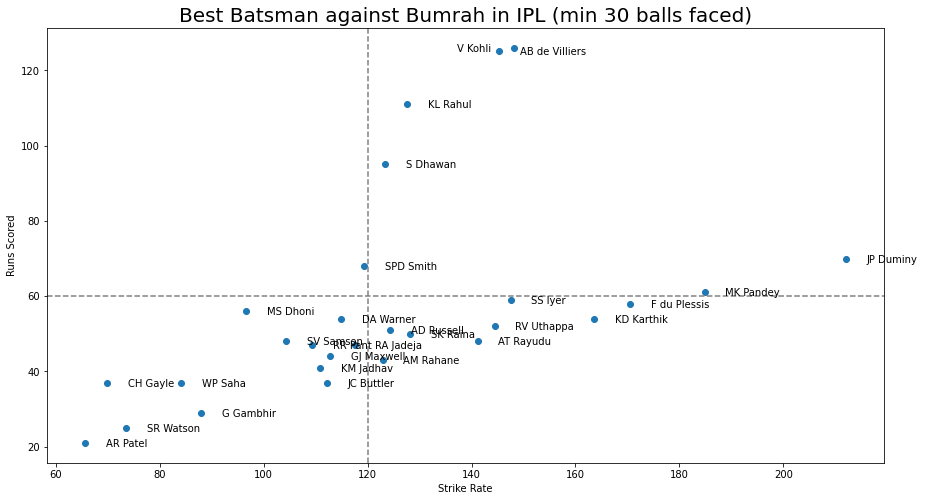

In [ ]:
plt.figure(figsize=(15,8))
plt.scatter(bdf5.strike_rate,bdf5.runs_off_bat)
plt.title('Best Batsman against Bumrah in IPL (min 30 balls faced)',fontsize=20)

for i in range(len(bdf5)):
#     plt.text(x,y,text)
    if bdf5['striker'][i] == 'V Kohli': 
            plt.text(bdf5['strike_rate'][i]-11,bdf5['runs_off_bat'][i]-1,bdf5['striker'][i])
    else:   
            plt.text(bdf5['strike_rate'][i]+4,bdf5['runs_off_bat'][i]-1,bdf5['striker'][i])



plt.axvline(120,ls ='--',color='grey')  
plt.axhline(60,ls ='--',color='grey')  
plt.xlabel('Strike Rate')
plt.ylabel('Runs Scored')
plt.show()

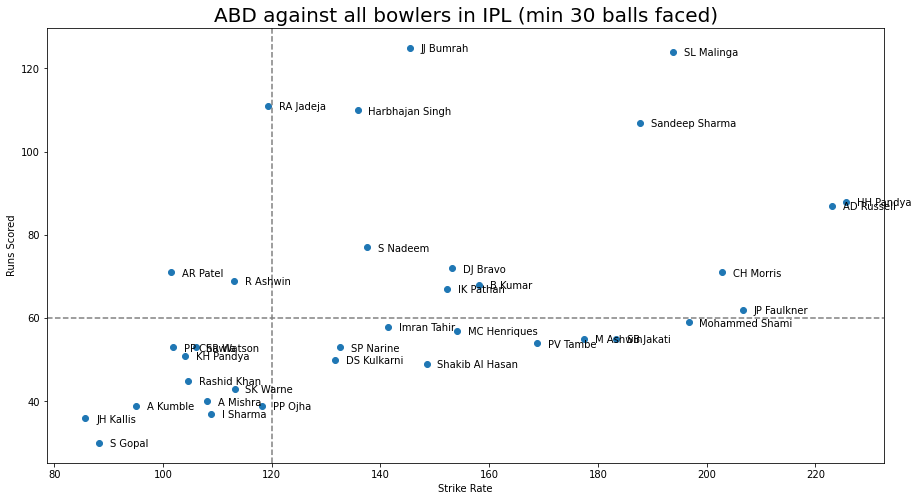

In [ ]:
plt.figure(figsize=(15,8))
plt.scatter(adf5.strike_rate,adf5.runs_off_bat)
plt.title('ABD against all bowlers in IPL (min 30 balls faced)',fontsize=20)

for i in range(len(adf5)):
#     plt.text(x,y,text)
  
     plt.text(adf5['strike_rate'][i]+2,adf5['runs_off_bat'][i]-1,adf5['bowler'][i])


plt.axvline(120,ls ='--',color='grey')  
plt.axhline(60,ls ='--',color='grey')  
plt.xlabel('Strike Rate')
plt.ylabel('Runs Scored')
plt.show()